##### Neural Network

In [1]:
# Misc imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NN Model imports
import torch
import torch.optim as optim
import itertools

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset

# Model evaluation imports
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

###### Data preparation

In [2]:
# Check where to import data from - if on colab then get it from the shared folder, otherwise from the relative local directory
import sys
if 'google.colab' in sys.modules:
    print("Running on Google Colab")

    from google.colab import drive
    drive.mount('/content/drive')

    df = pd.read_csv('/content/drive/MyDrive/MLBA/DS644-MLBA-Final-Project/data/dataset_final.csv')

else:
    print("Not running on Google Colab")
    df = pd.read_csv('../data/dataset_final.csv')

Running on Google Colab
Mounted at /content/drive


In [3]:
# Check if cuda is available - ran on Google Colab originally using A100 GPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [4]:
# Filtering the dataframe to only have houses that can  be purchased
print('======Before======')
print(df['status'].value_counts())

pre_status_drop = df['status'].shape[0]
print(f'There are {pre_status_drop} rows in the status column')

drop_vals = ['Foreclosure', 'Auction']
df_filtered = df[~df['status'].isin(drop_vals)].copy()

print()
print('======After======')
print(df_filtered['status'].value_counts())
# Checking how many null values
df_filtered.isnull().sum()
# Using the median for null values in area_sqft
df_filtered["area_sqft"] = df_filtered["area_sqft"].fillna(
    df_filtered["area_sqft"].median()
)
# Only had 1 null in longitude and latitude so decided to drop it
df_filtered = df_filtered.dropna(subset=["latitude", "longitude"])
df_filtered.isnull().sum()

post_status_drop = df_filtered['status'].shape[0]
print(f'Number of rows removed: {pre_status_drop - post_status_drop}')
print(f'There are {post_status_drop} rows in the status column')

print()
print(f'Null values remaining: {df_filtered.isnull().sum()[df_filtered.isnull().sum() > 0]}')



======Before======
status
House for sale           1447
Active                    350
Coming soon               219
Condo for sale             18
Active Under Contract      14
Townhouse for sale         14
New construction           13
Foreclosure                11
For sale by owner           8
Auction                     3
Coming Soon                 3
New                         1
Name: count, dtype: int64
There are 2101 rows in the status column

======After======
status
House for sale           1447
Active                    350
Coming soon               219
Condo for sale             18
Townhouse for sale         14
Active Under Contract      14
New construction           13
For sale by owner           8
Coming Soon                 3
New                         1
Name: count, dtype: int64
Number of rows removed: 15
There are 2086 rows in the status column

Null values remaining: zestimate    1037
dtype: int64


In [5]:
#Trying to get rid of extreme outliers on both the low and high ends of prices

# Minimum should be $35,500 but this is left as a safety
df_filtered = df_filtered[df_filtered['price'] > 10000]

cap = df_filtered['price'].quantile(0.99)
print(f"Capping at: ${cap:,.0f}")
df_filtered = df_filtered[df_filtered['price'] <= cap]

print(f"Rows remaining: {len(df_filtered)}")
print(df_filtered['price'].describe())

Capping at: $22,560,000
Rows remaining: 2065
count    2.065000e+03
mean     7.704434e+05
std      1.470751e+06
min      3.550000e+04
25%      3.350000e+05
50%      4.899000e+05
75%      7.500000e+05
max      2.250000e+07
Name: price, dtype: float64


In [6]:
'''
List of Columns for feature engineering
Index(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',
       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',
       'zestimate', 'detail_url', 'has_open_house', 'is_featured',
       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',
       'state_name', 'county_lookup', 'state_median_housing_value',
       'state_median_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates',
       'single_filer_brackets', 'married_filing_jointly_rates',
       'married_filing_jointly_brackets', 'state_avg_median_income'],
      dtype='object')
'''

"\nList of Columns for feature engineering\nIndex(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',\n       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',\n       'zestimate', 'detail_url', 'has_open_house', 'is_featured',\n       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',\n       'state_name', 'county_lookup', 'state_median_housing_value',\n       'state_median_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates',\n       'single_filer_brackets', 'married_filing_jointly_rates',\n       'married_filing_jointly_brackets', 'state_avg_median_income'],\n      dtype='object')\n"

In [7]:
# Dropping columns that are redundant or unhelpful
# Not sure if I should include zestimate, is_featured, and has_opened_house
# Also not sure about zipcode, city, and state name because they are string and if you one hot encode it would be a lot of columns
features = ['beds', 'baths', 'area_sqft', 'latitude', 'longitude', 'home_type',
            'days_on_zillow', 'state_median_housing_value', 'state_median_prop_tax_rate',
            'med_prop_tax_paid', 'state_code']
target = 'price'

RANDOM_STATE = 42

X = df_filtered[features]

# Adding dummy variables for one-hot encoding
X = pd.get_dummies(X, columns=["home_type", "state_code"], drop_first=True)

# Changing the target outcome to be between 0 and 1
y = np.log(df_filtered[target])

# Splitting the data with 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [8]:
# Confirming no underlying issues with the train/test datasets post-cleaning
train_df = X_train.copy()
test_df = X_test.copy()

train_df["price"] = y_train
test_df["price"] = y_test

print("=====TRAIN SUMMARY=====")
display(train_df.describe())

print("=====TEST SUMMARY=====")
display(test_df.describe())

=====TRAIN SUMMARY=====


,beds,baths,area_sqft,latitude,longitude,days_on_zillow,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,price
count,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000
mean,3.637409,2.838983,2529.863801,39.464291,-92.728468,21.327482,261310.169492,0.894192,2571.974879,13.156393
std,1.076653,1.245019,1705.541291,4.600150,16.017718,55.786865,105585.079224,0.506576,2028.996455,0.721837
min,1.000000,1.000000,572.000000,26.391940,-124.039010,-1.000000,134650.000000,0.280000,481.000000,10.477288
25%,3.000000,2.000000,1670.000000,36.021751,-105.049796,2.000000,169250.000000,0.520000,1134.000000,12.721886
50%,4.000000,3.000000,2206.000000,39.642481,-90.542760,4.000000,231900.000000,0.690000,1888.000000,13.101957
75%,4.000000,3.000000,2886.500000,42.801018,-78.606965,9.000000,335600.000000,1.070000,3293.500000,13.527828
max,17.000000,14.000000,29087.000000,48.790657,-69.429490,745.000000,587550.000000,2.030000,8055.000000,16.929026


=====TEST SUMMARY=====


,beds,baths,area_sqft,latitude,longitude,days_on_zillow,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,price
count,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,3.690073,2.877724,2563.815981,39.385927,-93.539261,22.871671,260734.019370,0.863765,2453.645278,13.177695
std,1.106391,1.405671,1639.820512,4.512633,16.096671,58.668441,109029.783714,0.505788,1965.765368,0.776309
min,1.000000,1.000000,634.000000,29.214384,-124.097000,0.000000,146400.000000,0.280000,481.000000,11.225243
25%,3.000000,2.000000,1658.000000,35.923950,-105.070450,2.000000,169250.000000,0.460000,921.000000,12.718597
50%,4.000000,3.000000,2206.000000,39.526510,-92.257900,4.000000,204700.000000,0.690000,1888.000000,13.093964
75%,4.000000,3.000000,2904.000000,42.028996,-80.871550,10.000000,390250.000000,1.070000,3293.500000,13.527827
max,10.000000,12.000000,16936.000000,48.719875,-72.035515,572.000000,481100.000000,2.030000,8055.000000,16.810993


In [9]:
# Scaling the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

###### Define Dataset and Neural Network class

Custom Dataset to use with Training/Testing DataLoader classes when actually training the model.

HousePriceNN is just a simple feedforwards Neural Net with a single output for the predicted house value (since it is not a classification problem).

In [10]:
class ZillowDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define the Regression Model
class HousePriceNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

###### Hyperparameter, feature testing, and 5-fold cross validation

Testing a small grid search on possible epoch training and learning rate values.

This could be much further extended, especially for learning rate but for the sake of this project was kept pretty simple to explore some values.

Additionally, 5-folds cross validation (using the built in sklearn KFold library) was chosen just simply based on the heuristic that 5 or 10 are generally good working values and 10 would add more time to training.

This exact same training loop is used for both the models that are optimized for MSE and MAE below

###### Fit best model using MSE as Criterion

Since we used both MSE and MAE as our evaluation metrics in previous models, we also want to try fitting the same neural network model using both metrics as our loss function to optimize for.

First up is a model that uses MSE as the loss function for training.

In [11]:
epochs_grid = [10, 20, 30, 40, 50]
lr_grid = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
batch_size = 32
k_folds = 5

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

best_avg_loss = float('inf')
best_params = {}
grid_results = []

print("Starting Grid Search...")

# Define the single feature set for the Neural Network, using the already scaled training features
X_nn_train = X_train_sc
y_nn_train = y_train # y_train is already log-transformed

# Determine input features count for the NN model
input_features_count = X_nn_train.shape[1]

for lr, epochs in itertools.product(lr_grid, epochs_grid):
    fold_losses = []
    print(f"\nTesting lr={lr}, epochs={epochs}...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn_train)):
        X_fold_train, y_fold_train = X_nn_train[train_idx], y_nn_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_nn_train[val_idx], y_nn_train.iloc[val_idx]

        train_dataset = ZillowDataset(X_fold_train, y_fold_train.values.reshape(-1, 1))
        val_dataset = ZillowDataset(X_fold_val, y_fold_val.values.reshape(-1, 1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = HousePriceNN(input_features=input_features_count).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_X), batch_y)
                loss.backward()
                optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                val_loss += criterion(model(batch_X), batch_y).item() * batch_X.size(0)

        fold_losses.append(val_loss / len(val_loader.dataset))

    avg_loss = sum(fold_losses) / k_folds

    print(f"Fold Losses: {fold_losses}")
    print(f"Average Loss: {avg_loss:.4f}")
    grid_results.append({'lr': lr, 'epochs': epochs, 'val_loss': avg_loss})

    if avg_loss < best_avg_loss:
        best_avg_loss = avg_loss
        best_params = {'lr': lr, 'epochs': epochs}

print(f"\nBest Params: lr={best_params['lr']}, epochs={best_params['epochs']} (Loss: {best_avg_loss:.4f})")

Starting Grid Search...

Testing lr=0.01, epochs=10...
Fold Losses: [0.9670164348315616, 1.0165723287627055, 0.8695444238908363, 0.2815766540440646, 0.47960461856740894]
Average Loss: 0.7229

Testing lr=0.01, epochs=20...
Fold Losses: [1.0520660618370754, 1.4627495160905977, 0.643343058499423, 0.33659344694831156, 0.47143099705378216]
Average Loss: 0.7932

Testing lr=0.01, epochs=30...
Fold Losses: [0.9280830225105372, 1.723985907894607, 0.934690142400337, 0.3097364997321909, 0.4787048940405701]
Average Loss: 0.8750

Testing lr=0.01, epochs=40...
Fold Losses: [0.9942072420592034, 1.3677467566512502, 0.9940293895475792, 0.2981635182192831, 0.46944894510688207]
Average Loss: 0.8247

Testing lr=0.01, epochs=50...
Fold Losses: [0.9672013573416051, 2.1562882218836297, 0.9723883498798717, 0.3619363192355994, 0.7481368919213612]
Average Loss: 1.0412

Testing lr=0.05, epochs=10...
Fold Losses: [2.135170724816913, 0.7014142976246571, 1.184064704360384, 0.4283832148169026, 0.8741543600053499]
Av

In [12]:
# Check best hyperparam combos for MSE model
df_results = pd.DataFrame(grid_results)
df_results.sort_values('val_loss').head(10)

,lr,epochs,val_loss
14,0.10,50,0.250823
17,0.15,30,0.255362
12,0.10,30,0.311265
19,0.15,50,0.320662
16,0.15,20,0.343826
18,0.15,40,0.368311
13,0.10,40,0.379132
29,0.25,50,0.473253
34,0.30,50,0.476453
22,0.20,30,0.499765


Based on the grid search, a learning rate of 0.01 and 50 epochs seemed to do the best on average with the 5-fold cross validation. These are the values we will use for the final testing set, while still acknowledging that due to the simple nature of this model and the lack of deep exploration into all feature combinations, better performing combinations will almost surely exist.

Next, we fit a model using the best hyperparameters from the grid search that used MSE as the loss function.

In [13]:
# Get the best configuration
best_epochs = best_params['epochs']
best_lr = best_params['lr']

final_train_dataset = ZillowDataset(X_train_sc, y_train.values.reshape(-1, 1))
test_dataset = ZillowDataset(X_test_sc, y_test.values.reshape(-1, 1))

final_train_loader = DataLoader(final_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

final_model = HousePriceNN(input_features=input_features_count).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

print(f"Training final model with lr={best_lr}, epochs={best_epochs}...")
for epoch in range(best_epochs):
    # Training
    final_model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in final_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = final_model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    train_losses.append(epoch_train_loss / len(final_train_dataset))

    # Testing per epoch
    final_model.eval()
    epoch_test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = final_model(batch_X)
            loss = criterion(preds, batch_y)
            epoch_test_loss += loss.item() * batch_X.size(0)

    test_losses.append(epoch_test_loss / len(test_dataset))


# Final RMSE calculation
final_model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        all_preds.append(final_model(batch_X).cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

# Convert log-transformed predictions and targets back to dollar values
preds_dollars = np.exp(np.vstack(all_preds))
targets_dollars = np.exp(np.vstack(all_targets))
rmse_dollars = np.sqrt(mean_squared_error(targets_dollars, preds_dollars))
print(f"\nFinal Test RMSE in Dollars: ${rmse_dollars:,.2f}")

# Save the best MSE model weights
torch.save(final_model.state_dict(), 'best_zillow_model_mse.pth')
print("MAE Model saved to 'best_zillow_model_mse.pth'")

Training final model with lr=0.1, epochs=50...

Final Test RMSE in Dollars: $1,566,501.05
MAE Model saved to 'best_zillow_model_mse.pth'


###### Fit best model using MAE as Criterion

For comparison, next we will fit a model using the same grid search setup with the only difference being MAE is used as the Criterion for optimizing.

In [14]:
# Grid search for MAE optimized model
epochs_grid = [10, 20, 30, 40, 50]
lr_grid = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
batch_size = 32
k_folds = 5

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

best_avg_loss_mae = float('inf')
best_params_mae = {}
grid_results_mae = []

print("Starting Grid Search for MAE model...")

for lr, epochs in itertools.product(lr_grid, epochs_grid):
    fold_losses_mae = []
    print(f"\nTesting lr={lr}, epochs={epochs}...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn_train)):
        X_fold_train, y_fold_train = X_nn_train[train_idx], y_nn_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_nn_train[val_idx], y_nn_train.iloc[val_idx]

        train_dataset = ZillowDataset(X_fold_train, y_fold_train.values.reshape(-1, 1))
        val_dataset = ZillowDataset(X_fold_val, y_fold_val.values.reshape(-1, 1))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model_mae = HousePriceNN(input_features=input_features_count).to(device)
        criterion_mae = nn.L1Loss() # L1Loss = MAE in PyTorch
        optimizer_mae = optim.Adam(model_mae.parameters(), lr=lr)

        model_mae.train()
        for epoch in range(epochs):
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer_mae.zero_grad()
                loss = criterion_mae(model_mae(batch_X), batch_y)
                loss.backward()
                optimizer_mae.step()

        model_mae.eval()
        val_loss_mae = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                val_loss_mae += criterion_mae(model_mae(batch_X), batch_y).item() * batch_X.size(0)

        fold_losses_mae.append(val_loss_mae / len(val_loader.dataset))

    avg_loss_mae = sum(fold_losses_mae) / k_folds

    print(f"Fold Losses MAE: {fold_losses_mae}")
    print(f"Average Loss MAE: {avg_loss_mae:.4f}")
    grid_results_mae.append({'lr': lr, 'epochs': epochs, 'val_loss_mae': avg_loss_mae})

    if avg_loss_mae < best_avg_loss_mae:
        best_avg_loss_mae = avg_loss_mae
        best_params_mae = {'lr': lr, 'epochs': epochs}

print(f"\nBest Params MAE: lr={best_params_mae['lr']}, epochs={best_params_mae['epochs']} (Loss: {best_avg_loss_mae:.4f})")

Starting Grid Search for MAE model...

Testing lr=0.01, epochs=10...
Fold Losses MAE: [0.5275685322608833, 0.7168548040519668, 0.5427782550002589, 0.4442631087519906, 0.5120269486398408]
Average Loss MAE: 0.5487

Testing lr=0.01, epochs=20...
Fold Losses MAE: [0.605501255239965, 0.66537188106073, 0.4995773783235839, 0.4508138132817818, 0.5017244571989233]
Average Loss MAE: 0.5446

Testing lr=0.01, epochs=30...
Fold Losses MAE: [0.536494301705202, 0.5951975688473335, 0.5609199057925831, 0.41160441889907373, 0.4858634952342871]
Average Loss MAE: 0.5180

Testing lr=0.01, epochs=40...
Fold Losses MAE: [0.4686057990771406, 0.5899518813791592, 0.803742689074892, 0.5415912460197102, 0.4341942411480528]
Average Loss MAE: 0.5676

Testing lr=0.01, epochs=50...
Fold Losses MAE: [0.4576201914300371, 0.608303407527889, 0.5816576065439166, 0.4509898962396564, 0.40512968157276963]
Average Loss MAE: 0.5007

Testing lr=0.05, epochs=10...
Fold Losses MAE: [0.6932399906780785, 0.9414108082246925, 0.77349

In [ ]:
# Check best hyperparam combos for MAE model
df_maeresults = pd.DataFrame(grid_results_mae)
df_maeresults.sort_values('val_loss_mae').head(10)

After doing grid search on the MAE model, the best parameter combination appears to be lr = .15 with 20 epochs, not too different from the MSE model which had the same best lr but 50 epochs instead.

Furthermore, the losses for 20 and 30 epochs with lr = .15 are quite close together, indicating a pretty trivial difference between one or the other in this case, so we will just go with the best.

In [15]:
# Get the best configuration for MAE model
best_epochs_mae = best_params_mae['epochs']
best_lr_mae = best_params_mae['lr']


final_train_dataset_mae = ZillowDataset(X_train_sc, y_train.values.reshape(-1, 1))
test_dataset_mae = ZillowDataset(X_test_sc, y_test.values.reshape(-1, 1))

final_train_loader_mae = DataLoader(final_train_dataset_mae, batch_size=batch_size, shuffle=True)
test_loader_mae = DataLoader(test_dataset_mae, batch_size=batch_size, shuffle=False)

final_model_mae = HousePriceNN(input_features=input_features_count).to(device)
optimizer_mae = optim.Adam(final_model_mae.parameters(), lr=best_lr_mae)
criterion_mae = nn.L1Loss() # Use MAE Loss for final model

train_losses_mae = []
test_losses_mae = []

print(f"Training final MAE model with lr={best_lr_mae}, epochs={best_epochs_mae}...")
for epoch in range(best_epochs_mae):
    # Training
    final_model_mae.train()
    epoch_train_loss_mae = 0
    for batch_X, batch_y in final_train_loader_mae:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer_mae.zero_grad()
        preds_mae = final_model_mae(batch_X)
        loss_mae = criterion_mae(preds_mae, batch_y)
        loss_mae.backward()
        optimizer_mae.step()
        epoch_train_loss_mae += loss_mae.item() * batch_X.size(0)

    train_losses_mae.append(epoch_train_loss_mae / len(final_train_dataset_mae))

    # Testing per epoch
    final_model_mae.eval()
    epoch_test_loss_mae = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader_mae:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds_mae = final_model_mae(batch_X)
            loss_mae = criterion_mae(preds_mae, batch_y)
            epoch_test_loss_mae += loss_mae.item() * batch_X.size(0)

    test_losses_mae.append(epoch_test_loss_mae / len(test_dataset_mae))


# Final RMSE calculation for MAE model
final_model_mae.eval()
all_preds_mae = []
all_targets_mae = []
with torch.no_grad():
    for batch_X, batch_y in test_loader_mae:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        all_preds_mae.append(final_model_mae(batch_X).cpu().numpy())
        all_targets_mae.append(batch_y.cpu().numpy())

# Convert log-transformed predictions and targets back to dollar values using np.exp
preds_dollars_mae = np.exp(np.vstack(all_preds_mae))
targets_dollars_mae = np.exp(np.vstack(all_targets_mae))
rmse_dollars_mae = np.sqrt(mean_squared_error(targets_dollars_mae, preds_dollars_mae))
print(f"\nFinal Test RMSE in Dollars (MAE Model): ${rmse_dollars_mae:,.2f}")

# Save the best MAE model weights
torch.save(final_model_mae.state_dict(), 'best_zillow_model_mae.pth')
print("MAE Model saved to 'best_zillow_model_mae.pth'")

Training final MAE model with lr=0.1, epochs=40...

Final Test RMSE in Dollars (MAE Model): $1,250,223.01
MAE Model saved to 'best_zillow_model_mae.pth'


###### MSE Model: Train/Test Loss Curves

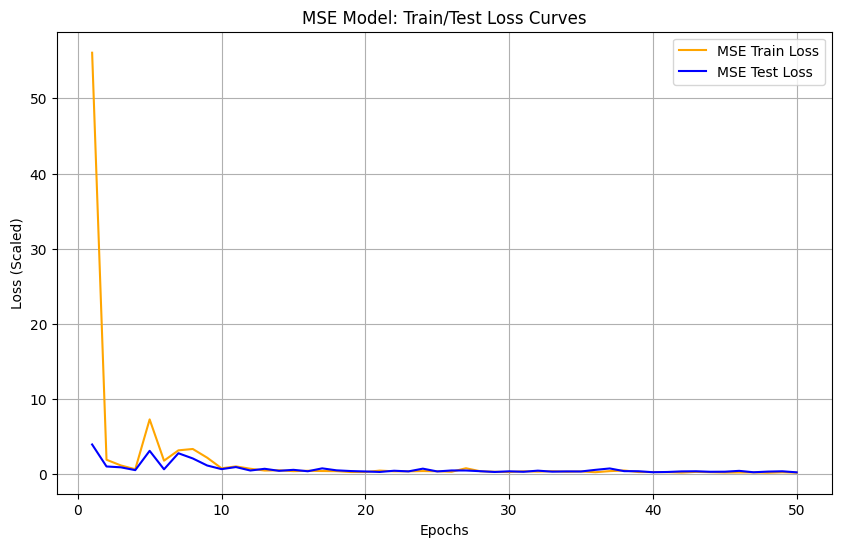

In [16]:
# Plot train/test loss over epochs for the MSE model
plt.figure(figsize=(10, 6))

plt.plot(range(1, best_epochs + 1), train_losses, label='MSE Train Loss', color='orange', linestyle='-')
plt.plot(range(1, best_epochs + 1), test_losses, label='MSE Test Loss', color='blue', linestyle='-')

plt.xlabel('Epochs')
plt.ylabel('Loss (Scaled)')
plt.title('MSE Model: Train/Test Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
sorted(test_losses)

[0.26311540044393145,
 0.2744115220143778,
 0.28199943340863787,
 0.3124962285990865,
 0.31425227784071363,
 0.3153891124679159,
 0.3390032864800377,
 0.33904267244997094,
 0.34942786904281914,
 0.3560397794186059,
 0.36393196328788924,
 0.3800255822933326,
 0.3819098978440929,
 0.3855004853977129,
 0.39090818852258363,
 0.3909087707141987,
 0.39188292766887395,
 0.4026981084889419,
 0.4052173782491799,
 0.4069676334286429,
 0.4100885755646315,
 0.4120443618470762,
 0.41542567669912345,
 0.4251252055601115,
 0.43422720940292026,
 0.46154635935372357,
 0.4659647909838697,
 0.4769679279073387,
 0.4889250860231552,
 0.5074822859383091,
 0.5094414056790655,
 0.513518692866942,
 0.5302627106844369,
 0.5571441533490474,
 0.5954589917353799,
 0.5979992137549864,
 0.6689407989274503,
 0.6923802519537346,
 0.7366561668837042,
 0.7543175852616243,
 0.7809843052963368,
 0.7943826300468629,
 0.9320845069954528,
 0.966792700365727,
 1.044678599724758,
 1.1756637970991342,
 2.1121244955871066,
 2.80

###### MAE Model: Train/Test Loss Curves

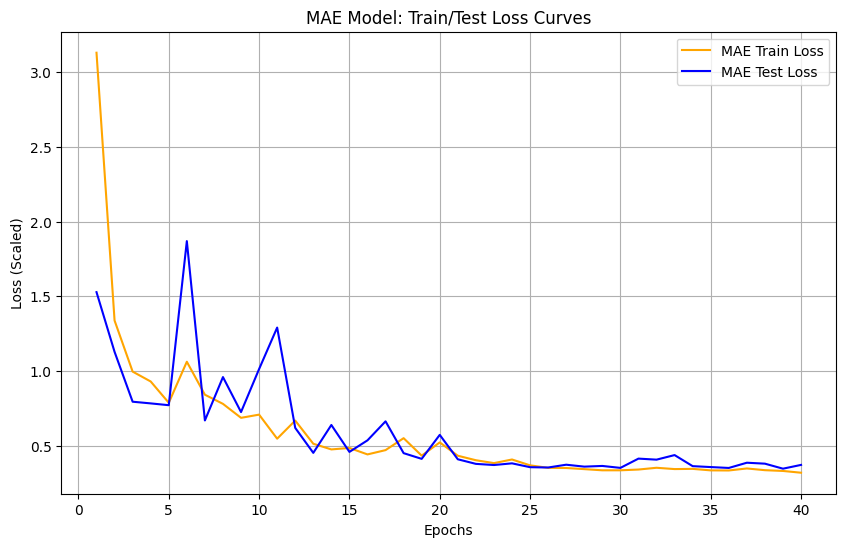

In [18]:
# Plot train/test loss over epochs for the MAE model
plt.figure(figsize=(10, 6))

plt.plot(range(1, best_epochs_mae + 1), train_losses_mae, label='MAE Train Loss', color='orange', linestyle='-')
plt.plot(range(1, best_epochs_mae + 1), test_losses_mae, label='MAE Test Loss', color='blue', linestyle='-')

plt.xlabel('Epochs')
plt.ylabel('Loss (Scaled)')
plt.title('MAE Model: Train/Test Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
sorted(test_losses)

[0.26311540044393145,
 0.2744115220143778,
 0.28199943340863787,
 0.3124962285990865,
 0.31425227784071363,
 0.3153891124679159,
 0.3390032864800377,
 0.33904267244997094,
 0.34942786904281914,
 0.3560397794186059,
 0.36393196328788924,
 0.3800255822933326,
 0.3819098978440929,
 0.3855004853977129,
 0.39090818852258363,
 0.3909087707141987,
 0.39188292766887395,
 0.4026981084889419,
 0.4052173782491799,
 0.4069676334286429,
 0.4100885755646315,
 0.4120443618470762,
 0.41542567669912345,
 0.4251252055601115,
 0.43422720940292026,
 0.46154635935372357,
 0.4659647909838697,
 0.4769679279073387,
 0.4889250860231552,
 0.5074822859383091,
 0.5094414056790655,
 0.513518692866942,
 0.5302627106844369,
 0.5571441533490474,
 0.5954589917353799,
 0.5979992137549864,
 0.6689407989274503,
 0.6923802519537346,
 0.7366561668837042,
 0.7543175852616243,
 0.7809843052963368,
 0.7943826300468629,
 0.9320845069954528,
 0.966792700365727,
 1.044678599724758,
 1.1756637970991342,
 2.1121244955871066,
 2.80

Both models are able to reach a stable training and test loss after about 10 epochs, from there the gains are extremely marginal, especially for the MSE model. It really did not need 50 epochs; even though that was the "best" performing model in the grid-search, it was trivially different from one that could be trained with 10 epochs.

The MSE model had a final RMSE on the full test data set of 1,286,591.82 while the MAE model had RMSE of 1,242,502.11. So with this metric, we do see slightly better overall predictions from the model that was optimized using the MAE/L1 loss function, with an improvement of about $40,000 in terms of RMSE.

###### Making final predictions on the complete dataset

Since the MAE model performed slightly better, we can use it now to make predictions on the whole dataset and see how they look in terms of dollars against the actual values.

In [20]:
# Save version of full dataset with only the features used in the final model.
# Use the original X (before train-test split, after one-hot encoding) and scale it using the previously fitted scaler
X_full = X # This 'X' is the one created in cell 14abe4f1, after get_dummies but before train-test split
X_full_scaled = scaler.transform(X_full) # 'scaler' was fit on X_train_sc in cell 7e4512dc

# Convert to PyTorch tensor
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32).to(device)

# Predict prices for all houses in the data
final_model_mae.eval()
with torch.no_grad():
    preds_full_log_scaled = final_model_mae(X_full_tensor).cpu().numpy()

# Undo log transformation to get actual dollar values.
preds_full_dollars = np.exp(preds_full_log_scaled)

# Create comparison for actual vs. predicted price
df_comparison = pd.DataFrame({
    'Actual Price': df_filtered['price'].values, # Use the original df_filtered price
    'Predicted Price': preds_full_dollars.flatten()
})
df_comparison['Difference'] = df_comparison['Actual Price'] - df_comparison['Predicted Price']

display(df_comparison.head(15))

,Actual Price,Predicted Price,Difference
0,447000,5.267882e+05,-7.978819e+04
1,2795000,1.122795e+06,1.672205e+06
2,1718000,7.409030e+05,9.770970e+05
3,899999,6.295931e+05,2.704059e+05
4,995000,5.585514e+05,4.364486e+05
5,349900,5.209162e+05,-1.710162e+05
6,989999,5.510258e+05,4.389732e+05
7,1070000,7.414995e+05,3.285005e+05
8,1899000,5.356711e+05,1.363329e+06
9,459000,6.195934e+05,-1.605934e+05
